# VQLS for Non-Linear Pendulum: AVL method

In this notebook, we study the nonlinear pendulum equation using a multi-step Variational Quantum Linear Solver (VQLS) approach - Auxiliary Variable Linearization (AVL) Method. We describe this method in the notebook `03_nonlinear_ode_linearization_methods.ipynb`. 

The nonlinear pendulum equation is

$$
\ddot{x} = -\omega^2 \sin x.
$$

Unlike the linear pendulum, the restoring force is nonlinear in the displacement. This makes the problem a useful next benchmark after the linear pendulum because it tests how VQLS behaves when the time-stepping update depends nonlinearly on the current state.

The goal of this notebook is to study a simple stepwise linearization strategy, called Method I, in which the nonlinear term $\sin x_n$ is evaluated at the current time step and treated as a known input to the linear system solved by VQLS.

We study how the VQLS solution depends on:

- the time-step size $h$,
- the frequency $\omega$,
- the ansatz depth,
- the condition number of the linear system,
- the VQLS residual,
- and the accumulated trajectory error.

## Method I: Treating the Nonlinear Term as a Known Stepwise Input

The nonlinear pendulum equation is rewritten as the first-order system

$$
\dot{x}=y,
$$

$$
\dot{y}=-\omega^2\sin x.
$$

Using forward Euler discretization,

$$
x_{n+1}=x_n+h y_n,
$$

$$
y_{n+1}=y_n-h\omega^2\sin(x_n).
$$

At each time step, $x_n$ and $y_n$ are known from the previous step. Therefore, $\sin(x_n)$ can also be evaluated classically at the beginning of the step. Once $\sin(x_n)$ is treated as a known input, the update equations can be written as a linear system $AX=b$.

This is the basic idea of Method I: the nonlinearity is not solved implicitly. Instead, the nonlinear force term is evaluated using the current state and included in the right-hand side/vector representation of the local linear system.

To make the vector dimension compatible with a three-qubit quantum state, we use an 8-dimensional vector. The extra components are auxiliary entries. The fifth component stores the value of $\sin(x_n)$, while the remaining added components are set to zero.

Then, the matrix equation becomes
\begin{align}
    \begin{pmatrix} 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\ 0 & 1 & 0 & 0 & 0 & 0 &0&0\\ -1 & -h & 1 & 0 & 0 &0&0&0 \\ 0 & -1 & 0 &1 & h\omega^2 &0&0&0\\ 0 & 0 & 0 & 0 & 1 &0&0&0 \\ 0&0&0&0&0&1&0&0 \\ 0&0&0&0&0&0&1&0 \\0&0&0&0&0&0&0&1  \end{pmatrix} 
    \begin{pmatrix} x_n \\ y_n \\ x_{n+1} \\ y_{n+1} \\ \sin x_n \\ 0\\0 \\0 \end{pmatrix} & = \begin{pmatrix} x_n \\ y_n \\ 0 \\ 0 \\ \sin x_n \\ 0\\ 0\\ 0 \end{pmatrix} \\
    A \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ X  \ \ \ \ & = \ \ \ \ \ \ b
\end{align}


## Imports and Basic Helper Functions

We first import the required numerical and quantum-computing libraries. The implementation uses Qiskit for quantum circuits and statevector simulation, SciPy for classical optimization, and NumPy/Pandas/Matplotlib for numerical analysis and plotting.

In [1]:
#Importing necessary packages and functions
from qiskit import QuantumCircuit,transpile
import numpy as np
from qiskit.quantum_info import SparsePauliOp, DensityMatrix, Statevector
from qiskit.circuit.library import TwoLocal,n_local
from scipy.optimize import minimize
from qiskit_aer.primitives import EstimatorV2
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator

estimator = EstimatorV2()


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import time
import datetime
import pickle
import os


## Constructing the Local Linear System

The function below constructs the matrix \(A\) for the local Euler update. The unknown vector contains the current state, the next state, and an auxiliary entry for the nonlinear term:

$$
X =
(x_n, y_n, x_{n+1}, y_{n+1}, \sin x_n, 0,0,0)^T.
$$

The matrix rows enforce:

$$
x_{n+1}-x_n-hy_n=0,
$$

$$
y_{n+1}-y_n+h\omega^2\sin(x_n)=0.
$$

The auxiliary identity rows are included so that the system dimension is $8=2^3$, which can be represented using three qubits.

The right-hand side vector contains the current state and the value of the nonlinear term evaluated at the current position:

$$
b_n =
(x_n, y_n, 0,0,\sin x_n,0,0,0)^T.
$$

At each time step, after obtaining $x_{n+1}$, the nonlinear term must be recomputed as $\sin(x_{n+1})$ before advancing to the next step.

In [3]:
#creating Matrix A
def create_matrix_nonlinear(omega,h,n):
    mat = np.zeros((n,n))
    for i in range(n):
        mat[i,i] = 1
    mat[2,0] = -1
    mat[2,1] = - h
    mat[3,4] = h*omega*omega
    mat[3,1] = -1
    return mat

#creating b vector
def create_bvec_nonlinear(xi,yi):
    b = np.array([xi,yi,0,0,np.sin(xi),0,0,0],dtype = float)
    return b

#Creating function to normalize a vector
def normalize(v):
    return v / np.linalg.norm(v)

#generating a classical solution (raw and normalized) 
def classical_solution_raw(A, b):
    x = np.linalg.solve(A, b)
    return x

def classical_solution(A, b):
    x = np.linalg.solve(A, b)
    return normalize(x)

#defining dagger of an opertor
def A_dagger(A_op):
    return A_op.adjoint()

In [4]:
#Generating pauli terms from an operator
def op_from_matrix(M):
    return SparsePauliOp.from_operator(M)

def n_of_qubits(n):
    return int(np.log2(n))

#Creating an identity pauli term, i.e II or III or ... 
def identity_op(n_qubits):
    return SparsePauliOp.from_list([("I"*n_qubits, 1.0)])

## VQLS Cost Hamiltonian

The VQLS algorithm approximates the solution of a linear system by preparing a parameterized quantum state $|x(\theta)\rangle$. The parameters are optimized so that $A|x(\theta)\rangle$ becomes proportional to the normalized right-hand side state $|b\rangle$.

Here we use a projector-based cost function of the form

$$
C(\theta) =
\langle x(\theta)|
A^\dagger
\left(I - |b\rangle\langle b|\right)
A
|x(\theta)\rangle.
$$

This cost becomes small when $A|x(\theta)\rangle$ is aligned with $|b\rangle$. The operator corresponding to this expression is constructed as a Pauli operator so that its expectation value can be estimated using the quantum circuit.

In [5]:
#Creating cost Hamiltonian matrix
def cost_hamiltonian(A_op, b_state,n):
    n_qubits = n_of_qubits(n)
    I = identity_op(n_qubits)
    B_dm = DensityMatrix(b_state)           # |b><b|
    B_op = op_from_matrix(B_dm)
    A_dag = A_dagger(A_op)
    H = A_dag @ (I - B_op) @ A_op
    # hermitianize & real-coeff cleanup
    H = 0.5*(H + H.adjoint())
    H = SparsePauliOp(H.paulis, coeffs=np.real(H.coeffs))
    return H

## Ansatz Circuit

The variational ansatz prepares the trial solution state $|x(\theta)\rangle$. In this notebook, we use an $n$-local circuit built from $R_y$ rotations and CNOT entangling gates with linear entanglement.

The ansatz depth is controlled by the parameter `reps`. Increasing `reps` can improve expressibility, but it also increases the number of variational parameters and the optimization cost.

In [6]:
#Creating ansatz (n-local circuit)
def make_ansatz(n_qubits,reps):
    return n_local(n_qubits, rotation_blocks="ry", entanglement_blocks="cx", entanglement="circular", reps=reps,insert_barriers = False)

#Pauli Count
def pauli_term_count(op: SparsePauliOp):
    return len(op.paulis)

#Generating statevector from parameters from the solution
def state_from_params(ansatz, params):
    qc = QuantumCircuit(ansatz.num_qubits)
    qc.compose(ansatz.assign_parameters(params), inplace=True)
    return Statevector.from_instruction(qc).data


## Multi-Step VQLS for the Nonlinear Pendulum

The function below implements the multi-step VQLS method for the nonlinear pendulum using Method I.

At each time step:

1. The current state $(x_n,y_n)$ is used to evaluate $\sin(x_n)$.
2. A local linear system $AX=b_n$ is constructed.
3. VQLS is used to solve the linear system approximately.
4. The next state $(x_{n+1},y_{n+1})$ is extracted from the solution vector.
5. The nonlinear term is recomputed as $\sin(x_{n+1})$.
6. The updated state is used to construct the next right-hand side vector.

The residual $\|AX-b\| $ measures the local accuracy of the VQLS solution at each time step, while the trajectory error measures the accumulated difference between the VQLS trajectory and the classical Euler trajectory.

In [7]:
#Function to run VQLS
def run_vqls_nonlinear(n,xi,yi,h,omega,nf,reps,cost_type="projector", optimizer="COBYLA",maxiter = 600,seed = 0):
    np.random.seed(seed)

    #matrix and vector
    Amat = create_matrix_nonlinear(omega,h,n)
    b_vec_q = create_bvec_nonlinear(xi,yi)
    b_vec_cl = create_bvec_nonlinear(xi,yi)
    A_op = op_from_matrix(Amat)
    n_q = n_of_qubits(n)
    I2 = identity_op(n_q)
    kappa = np.linalg.cond(Amat)

    #making ansatz
    ansatz = make_ansatz(n_q,reps)

    #Define the cost function
    def costfunc(params):
        if cost_type == "projector":
            job = estimator.run([(ansatz,Ham,params)])
            result = job.result()
            value  = result[0].data.evs
            return value

    #Creating a VQLS loop
    x_vqls = np.zeros(nf)
    x_vqls[0] = b_vec_q[0] 
    x_cl = np.zeros(nf)
    x_cl[0] = b_vec_cl[0]

    costs = []
    iters = []
    residuals = []
    
    for i in range(1,nf):
        B_vec = normalize(b_vec_q)

        #Cost Hamiltonian
        Ham = cost_hamiltonian(A_op, B_vec,n)
        
        #Optimization
        if i == 1:
            initial_params = np.random.uniform(0, 2*np.pi, ansatz.num_parameters)
        else:
            initial_params = optimal_params
    
        res = minimize(costfunc, initial_params, method=optimizer,options={'maxiter': maxiter,'tol': 1e-8})
    
        #finding optimal parameters
        optimal_params = res.x
        # Evaluate final state
        x_quant = state_from_params(ansatz, optimal_params)   
    
        #finding the alpha for AX = alpha b and find the unormalized quantum solution
        xhat = x_quant
        Axhat = Amat @ xhat
        c = np.vdot(b_vec_q, Axhat) / np.vdot(Axhat, Axhat)
        x_q = c * xhat
        
        #Creating a real quantum solution by removing img parts
        x_qm = np.zeros(n)
        for k in range(n):
            x_qm[k] = x_q[k].real

        costs.append(res.fun)
        iters.append(res.nfev)
        residuals.append(np.linalg.norm(Amat @ x_q - b_vec_q))

        #Finding classical solution, storing in x_fin_cl and updateing classical b vector
        x_cl_one = classical_solution_raw(Amat, b_vec_cl)
        b_vec_cl[0] = x_cl_one[2]
        b_vec_cl[1] = x_cl_one[3]
        b_vec_cl[4] = np.sin(x_cl_one[2])
        x_cl[i] = x_cl_one[2]

        #update B vector and store the final solution in x_fin
        b_vec_q[0] = x_qm[2]
        b_vec_q[1] = x_qm[3]
        b_vec_q[4] = np.sin(x_qm[2])
        x_vqls[i] = x_qm[2]
    
    #Errors
    trajectory_error = np.abs(x_cl - x_vqls)
    final_error = np.abs(x_cl[-1] - x_vqls[-1])
    mean_error = np.mean(np.abs(x_cl - x_vqls))
    max_error = np.max(np.abs(x_cl - x_vqls))
    
    return {
        "n": n,
        "h": h,
        "omega": omega,
        "condition_number": kappa,
        "reps": reps,
        "cost_type": cost_type,
        "optimizer": optimizer,
        "costs": np.array(costs),
        "iters": np.array(iters),
        "residuals": np.array(residuals),
        "x_vqls": x_vqls,
        "x_cl": x_cl,
        "trajectory_err":trajectory_error,
        "fin_err": final_error,
        "mean_err":mean_error,
        "max_err":max_error
    }

## Sanity Check

We first run the solver for a small number of time steps to verify that the code executes correctly and that the VQLS solution agrees with the classical linear solve for a simple parameter choice.

In [6]:
run_vqls_nonlinear(n=8,xi=1,yi=0,h=0.001,omega=1,nf=4,reps=4,cost_type="projector", optimizer="COBYLA",maxiter=600,seed = 0)

{'n': 8,
 'h': 0.001,
 'omega': 1,
 'condition_number': np.float64(2.6192058903956346),
 'reps': 4,
 'cost_type': 'projector',
 'optimizer': 'COBYLA',
 'costs': array([-3.33066907e-16,  4.45476989e-15, -9.71445147e-17]),
 'iters': array([590, 483, 431]),
 'residuals': array([5.32173678e-08, 1.19204555e-07, 5.73657618e-08]),
 'x_vqls': array([1.        , 0.99999997, 0.99999913, 0.99999745]),
 'x_cl': array([1.        , 1.        , 0.99999916, 0.99999748]),
 'trajectory_err': array([0.00000000e+00, 2.71707762e-08, 2.51479120e-08, 2.73491438e-08]),
 'fin_err': np.float64(2.7349143838506507e-08),
 'mean_err': np.float64(1.9916957999521756e-08),
 'max_err': np.float64(2.7349143838506507e-08)}

## Parameter Scan

We now run the nonlinear pendulum VQLS solver for a grid of parameter values. The scan varies the time-step size $h$, frequency $\omega$, and ansatz depth `reps`.

The purpose of this scan is to identify parameter regimes where the VQLS solution remains accurate and regimes where the method becomes unstable or inaccurate.

The results are saved after each run because the simulations are computationally expensive.

In [ ]:
#For different values of h, omega, ansatz depth (reps) and cost function types

# file name
save_file = "results_nonlinear_pd3.pkl"

# Load existing results if file exists
if os.path.exists(save_file):
    with open(save_file, "rb") as f:
        results_nl = pickle.load(f)
    print(f"Loaded {len(results_nl)} existing results")
else:
    results_nl = []

#parameter lists
#parameter lists
h_list = [0.001, 0.01, 0.1]
omega_list = [0.5, 1, 3, 5]
reps_list = [1, 2, 3]

#h_list = [0.001] #one h value
#omega_list = [1]
#reps_list = [3]

nf_one = 30

total_cases = len(h_list) * len(omega_list) * len(reps_list)
print(f"Total number of parameter cases: {total_cases}")

time_all = 0

# parameter loops
for h in h_list:
    for omega in omega_list:
        for reps in reps_list:
            print(f"Running: h={h}, omega={omega}, reps={reps}")

            t0 = time.time()

            out = run_vqls_nonlinear(
                n=8,xi=1,yi=0, h=h, omega=omega, nf=nf_one, reps=reps, cost_type="projector", optimizer="COBYLA", maxiter=600,seed=1)

            t1 = time.time()

            # Add metadata
            out["runtime_sec"] = t1 - t0
            out["runtime_min"] = (t1 - t0) / 60
            out["timestamp"] = time.time()
            out["time_str"] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            out["nf"] = nf_one

            results_nl.append(out)

            print(f"Done in {out['runtime_sec']:.2f} sec")

            time_all = time_all + out["runtime_min"]

            # Save after each case
            with open(save_file, "wb") as f:
                pickle.dump(results_nl, f)

print("All runs complete!")
print(f"Done in {time_all} min")

Loaded 11 existing results
Total number of parameter cases: 36
Running: h=0.001, omega=0.5, reps=1


In [8]:
# For different values of h, omega, ansatz depth (reps)

save_file = "results_nonlinear_pd3.pkl"

# Load existing results if file exists
if os.path.exists(save_file):
    with open(save_file, "rb") as f:
        results_nl = pickle.load(f)
    print(f"Loaded {len(results_nl)} existing results")
else:
    results_nl = []


def already_done(results, h, omega, reps, nf):
    """
    Check whether a given parameter case has already been completed.
    """
    for r in results:
        if (
            r["h"] == h
            and r["omega"] == omega
            and r["reps"] == reps
            and r.get("nf", None) == nf
        ):
            return True
    return False


# Parameter lists
h_list = [0.001, 0.01, 0.1]
omega_list = [0.5, 1, 3, 5]
reps_list = [1, 2, 3]

nf_one = 30
maxiter = 600

total_cases = len(h_list) * len(omega_list) * len(reps_list)
completed_cases = 0
skipped_cases = 0
time_all = 0.0

print(f"Total possible parameter cases: {total_cases}")

for h in h_list:
    for omega in omega_list:
        for reps in reps_list:

            if already_done(results_nl, h, omega, reps, nf_one):
                print(f"Skipping completed case: h={h}, omega={omega}, reps={reps}, nf={nf_one}")
                skipped_cases += 1
                continue

            print(f"\nRunning: h={h}, omega={omega}, reps={reps}, nf={nf_one}")

            t0 = time.time()

            try:
                out = run_vqls_nonlinear(
                    n=8,
                    xi=1,
                    yi=0,
                    h=h,
                    omega=omega,
                    nf=nf_one,
                    reps=reps,
                    cost_type="projector",
                    optimizer="COBYLA",
                    maxiter=maxiter,
                    seed=1
                )

                t1 = time.time()

                # Add metadata
                out["runtime_sec"] = t1 - t0
                out["runtime_min"] = (t1 - t0) / 60
                out["timestamp"] = time.time()
                out["time_str"] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                out["nf"] = nf_one
                out["maxiter"] = maxiter
                out["status"] = "completed"

                results_nl.append(out)

                completed_cases += 1
                time_all += out["runtime_min"]

                print(f"Completed in {out['runtime_sec']:.2f} sec = {out['runtime_min']:.2f} min")

                # Save immediately after each completed case
                with open(save_file, "wb") as f:
                    pickle.dump(results_nl, f)

                print(f"Saved results to {save_file}")

            except Exception as e:
                t1 = time.time()

                failed_out = {
                    "h": h,
                    "omega": omega,
                    "reps": reps,
                    "nf": nf_one,
                    "maxiter": maxiter,
                    "status": "failed",
                    "error_message": str(e),
                    "runtime_sec": t1 - t0,
                    "runtime_min": (t1 - t0) / 60,
                    "timestamp": time.time(),
                    "time_str": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                }

                results_nl.append(failed_out)

                with open(save_file, "wb") as f:
                    pickle.dump(results_nl, f)

                print(f"Failed case: h={h}, omega={omega}, reps={reps}")
                print("Error:", e)
                print("Failure saved. Continuing to next case.")

print("\nAll requested runs complete.")
print(f"New completed cases in this run: {completed_cases}")
print(f"Skipped completed cases: {skipped_cases}")
print(f"Runtime for new completed cases: {time_all:.2f} min")

Loaded 11 existing results
Total possible parameter cases: 36
Skipping completed case: h=0.001, omega=0.5, reps=1, nf=30
Skipping completed case: h=0.001, omega=0.5, reps=2, nf=30
Skipping completed case: h=0.001, omega=0.5, reps=3, nf=30
Skipping completed case: h=0.001, omega=1, reps=1, nf=30
Skipping completed case: h=0.001, omega=1, reps=2, nf=30
Skipping completed case: h=0.001, omega=1, reps=3, nf=30
Skipping completed case: h=0.001, omega=3, reps=1, nf=30
Skipping completed case: h=0.001, omega=3, reps=2, nf=30
Skipping completed case: h=0.001, omega=3, reps=3, nf=30
Skipping completed case: h=0.001, omega=5, reps=1, nf=30
Skipping completed case: h=0.001, omega=5, reps=2, nf=30

Running: h=0.001, omega=5, reps=3, nf=30
Completed in 1273.22 sec = 21.22 min
Saved results to results_nonlinear_pd3.pkl

Running: h=0.01, omega=0.5, reps=1, nf=30
Completed in 285.62 sec = 4.76 min
Saved results to results_nonlinear_pd3.pkl

Running: h=0.01, omega=0.5, reps=2, nf=30
Completed in 486.53

# Comparison Plots

In [3]:
# Load saved results
with open("results_nonlinear_pd3.pkl", "rb") as f:
    results_nl = pickle.load(f)

In [4]:


# Convert results list into summary dataframe
rows = []

for r in results_nl:
    rows.append({
        "h": r["h"],
        "omega": r["omega"],
        "reps": r["reps"],
        "condition_number": float(r["condition_number"]),

        "final_cost": float(r["costs"][-1]),
        "mean_cost": float(np.mean(r["costs"])),
        "max_cost": float(np.max(r["costs"])),

        "final_residual": float(r["residuals"][-1]),
        "mean_residual": float(np.mean(r["residuals"])),
        "max_residual": float(np.max(r["residuals"])),

        "final_error": float(r["fin_err"]),
        "mean_error": float(r["mean_err"]),
        "max_error": float(r["max_err"]),

        "mean_iters": float(np.mean(r["iters"])),
        "max_iters": float(np.max(r["iters"])),
        "total_iters": float(np.sum(r["iters"])),
    })

df = pd.DataFrame(rows)
df = df.sort_values(["h", "omega", "reps"])

print(df.head())

       h  omega  reps  condition_number    final_cost     mean_cost  \
0  0.001    0.5     1          2.619205  6.240711e-08  5.072038e-08   
1  0.001    0.5     2          2.619205  1.254552e-14  3.445496e-13   
2  0.001    0.5     3          2.619205  1.351697e-14  3.981489e-15   
3  0.001    1.0     1          2.619206  9.993810e-07  8.119520e-07   
4  0.001    1.0     2          2.619206  4.191092e-15  4.531385e-14   

       max_cost  final_residual  mean_residual  max_residual   final_error  \
0  6.240711e-08    4.110971e-04   3.570330e-04  4.110971e-04  7.776333e-05   
1  9.670681e-12    1.879517e-07   3.463290e-07  5.117594e-06  9.014864e-07   
2  1.351697e-14    1.963716e-07   1.058365e-07  1.985259e-07  1.517363e-07   
3  9.993810e-07    1.645183e-03   1.428500e-03  1.645183e-03  3.854183e-04   
4  1.126141e-12    1.267973e-07   1.940169e-07  1.746635e-06  2.987424e-07   

     mean_error     max_error  mean_iters  max_iters  total_iters  
0  2.483528e-05  7.776333e-05  149.6

## VQLS Trajectory vs Classical Trajectory

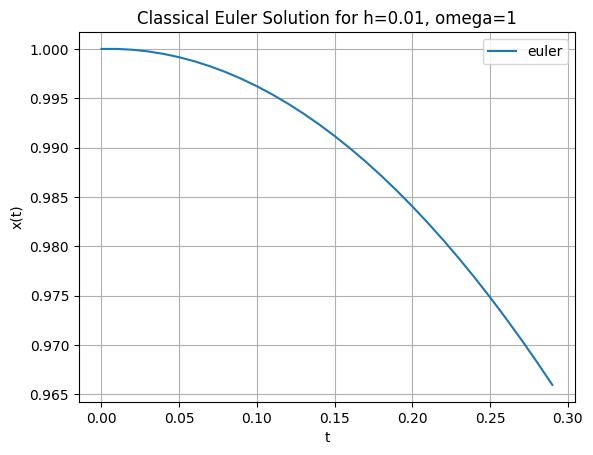

In [17]:
#Classical Euler solution 
import numpy as np

h_1 = 0.01
omega_1 = 1
nf_1 = 30
t_1 = np.arange(nf_1)*h_1

# explicit Euler for comparison
x_e = np.zeros(nf_1); y_e = np.zeros(nf_1)
x_e[0]=1.0; y_e[0]=0.0
for i in range(nf_1-1):
    x_e[i+1] = x_e[i] + h_1*y_e[i]
    y_e[i+1] = y_e[i] - h_1*(omega_1**2)*np.sin(x_e[i])

#Classical Euler Solution Plot

plt.plot(t_1,x_e,label='euler')

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title(f"Classical Euler Solution for h={h_1}, omega={omega_1}")
plt.legend()
plt.grid(True)
plt.show()


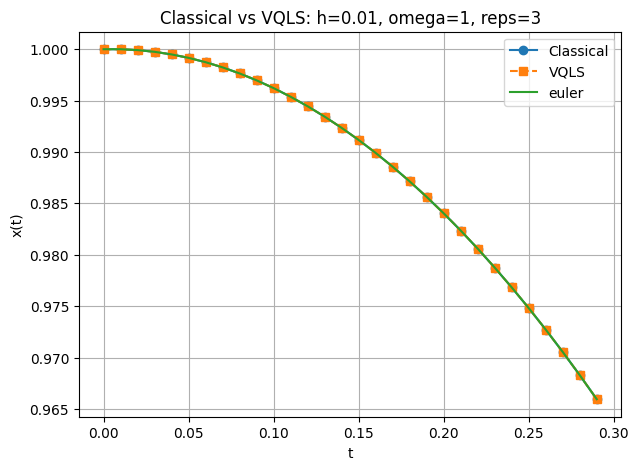

In [18]:
#Consider the same h and omega values as before for a comparison
h_target = 0.01
omega_target = 1
reps_target = 3

for r in results_nl:
    if r["h"] == h_target and r["omega"] == omega_target and r["reps"] == reps_target:
        case = r
        break

nf = len(case["x_vqls"])
t = np.arange(nf) * h_target

plt.figure(figsize=(7,5))
plt.plot(t, case["x_cl"], marker="o", label="Classical") #obtained by inversing Ax=b step by step
plt.plot(t, case["x_vqls"], marker="s",linestyle="--", label="VQLS") #obtained by solving Ax=b step by step using VQLS
plt.plot(t,x_e,label='euler') #Obtained by classically generating solution
    

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title(f"Classical vs VQLS: h={h_target}, omega={omega_target}, reps={reps_target}")
plt.legend()
plt.grid(True)
plt.show()


## Error vs condition number

It describes the accuracy of the time trajectory.

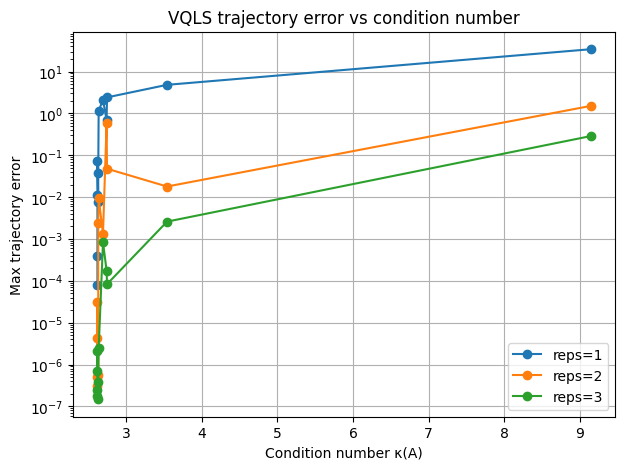

In [11]:
plt.figure(figsize=(7,5))

for reps in sorted(df["reps"].unique()):
    sub = df[df["reps"] == reps]
    plt.plot(
        sub["condition_number"],
        sub["max_error"], marker ="o",
        label=f"reps={reps}"
    )

plt.yscale("log")
plt.xlabel("Condition number κ(A)")
plt.ylabel("Max trajectory error")
plt.title("VQLS trajectory error vs condition number")
plt.legend()
plt.grid(True)
plt.show()

## Residual error vs condition number

This describes the accuracy of linear solver (VQLS)

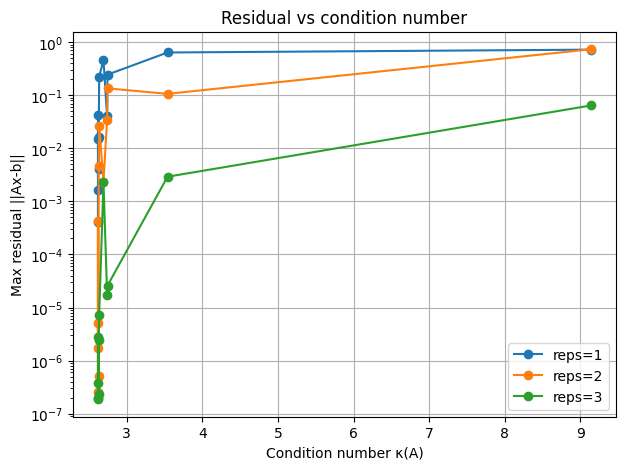

In [12]:
plt.figure(figsize=(7,5))

for reps in sorted(df["reps"].unique()):
    sub = df[df["reps"] == reps]
    plt.plot(
        sub["condition_number"],
        sub["max_residual"],marker ="o",
        label=f"reps={reps}"
    )

plt.yscale("log")
plt.xlabel("Condition number κ(A)")
plt.ylabel("Max residual ||Ax-b||")
plt.title("Residual vs condition number")
plt.legend()
plt.grid(True)
plt.show()

## Optimization effort vs condition number

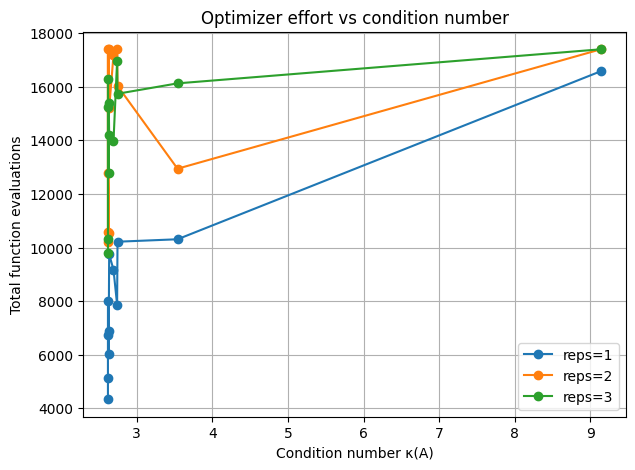

In [13]:
plt.figure(figsize=(7,5))

for reps in sorted(df["reps"].unique()):
    sub = df[df["reps"] == reps]
    plt.plot(
        sub["condition_number"],
        sub["total_iters"],marker="o",
        label=f"reps={reps}"
    )

plt.xlabel("Condition number κ(A)")
plt.ylabel("Total function evaluations")
plt.title("Optimizer effort vs condition number")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
df.groupby("reps")[["max_error", "max_residual", "total_iters","condition_number"]].mean()

,max_error,max_residual,total_iters,condition_number
reps,,,,
1,0.012987,0.170569,2224.416667,11.649277
2,0.015070,0.119975,2267.500000,11.649277
3,0.009337,0.089844,2397.500000,11.649277
4,1.774288,3.527535,2397.083333,11.649277


## Error vs reps

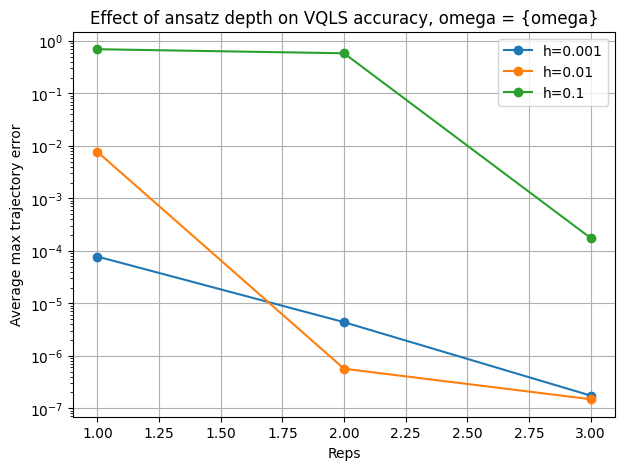

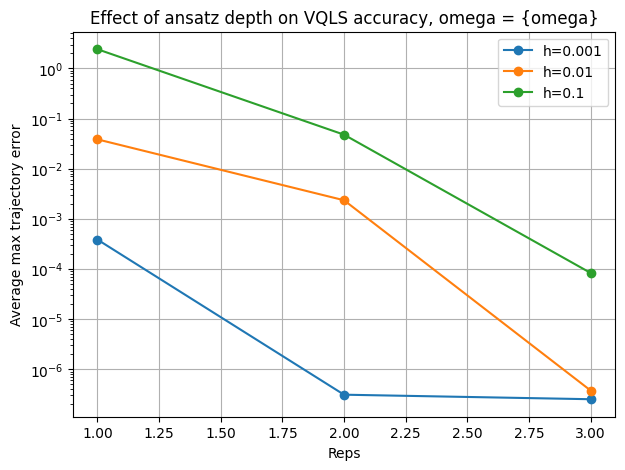

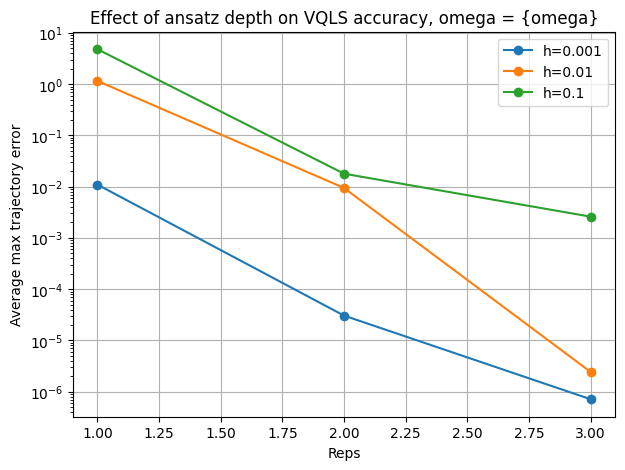

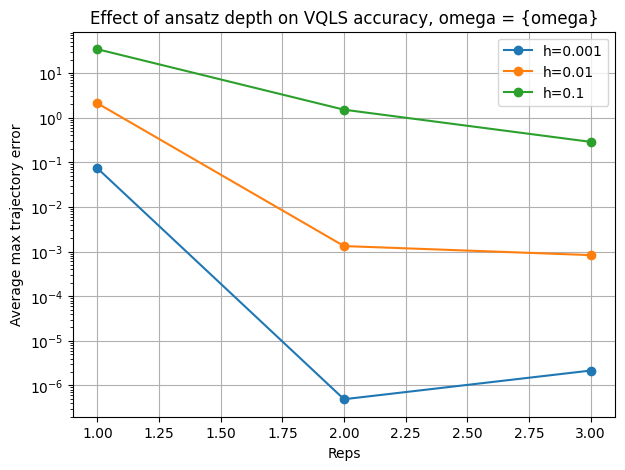

In [7]:
for omega in sorted(df["omega"].unique()):
    plt.figure(figsize=(7,5))
    
    for h in sorted(df["h"].unique()):
        sub = df[(df["h"] == h) & (df["omega"] == omega)]
        grouped = sub.groupby("reps")["max_error"].mean()
    
        plt.plot(
            grouped.index,
            grouped.values,
            marker="o",
            label = f"h={h}"
        )
    
    plt.yscale("log")
    plt.xlabel("Reps")
    plt.ylabel("Average max trajectory error")
    plt.title("Effect of ansatz depth on VQLS accuracy, omega = {omega}")
    plt.legend()
    plt.grid(True)
    plt.show()

## Heat Map (for fixed reps)

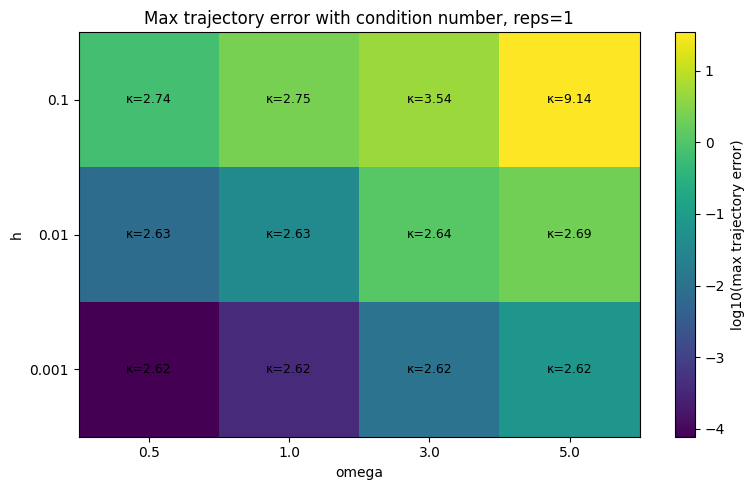

In [8]:
reps_fixed = 1

sub = df[df["reps"] == reps_fixed]

err_pivot = sub.pivot(index="h", columns="omega", values="max_error")
kappa_pivot = sub.pivot(index="h", columns="omega", values="condition_number")

plt.figure(figsize=(8,5))

im = plt.imshow(
    np.log10(err_pivot.values),
    aspect="auto",
    origin="lower"
)

plt.colorbar(im, label="log10(max trajectory error)")

plt.xticks(range(len(err_pivot.columns)), err_pivot.columns)
plt.yticks(range(len(err_pivot.index)), err_pivot.index)

plt.xlabel("omega")
plt.ylabel("h")
plt.title(f"Max trajectory error with condition number, reps={reps_fixed}")

# Add condition number text in each box
for i in range(len(err_pivot.index)):
    for j in range(len(err_pivot.columns)):
        kappa_val = kappa_pivot.values[i, j]
        plt.text(
            j, i,
            f"κ={kappa_val:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()

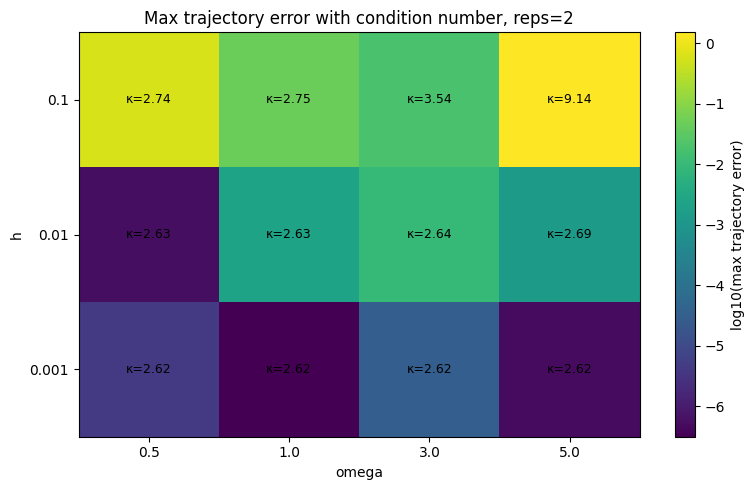

In [9]:
reps_fixed = 2

sub = df[df["reps"] == reps_fixed]

err_pivot = sub.pivot(index="h", columns="omega", values="max_error")
kappa_pivot = sub.pivot(index="h", columns="omega", values="condition_number")

plt.figure(figsize=(8,5))

im = plt.imshow(
    np.log10(err_pivot.values),
    aspect="auto",
    origin="lower"
)

plt.colorbar(im, label="log10(max trajectory error)")

plt.xticks(range(len(err_pivot.columns)), err_pivot.columns)
plt.yticks(range(len(err_pivot.index)), err_pivot.index)

plt.xlabel("omega")
plt.ylabel("h")
plt.title(f"Max trajectory error with condition number, reps={reps_fixed}")

# Add condition number text in each box
for i in range(len(err_pivot.index)):
    for j in range(len(err_pivot.columns)):
        kappa_val = kappa_pivot.values[i, j]
        plt.text(
            j, i,
            f"κ={kappa_val:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()

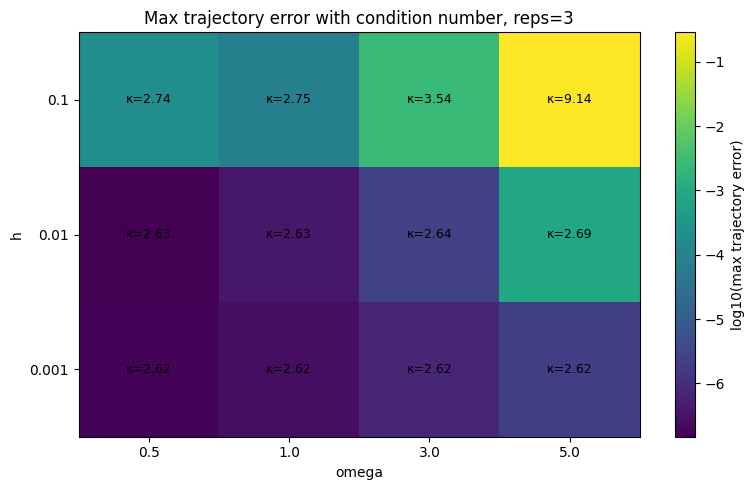

In [10]:
reps_fixed = 3

sub = df[df["reps"] == reps_fixed]

err_pivot = sub.pivot(index="h", columns="omega", values="max_error")
kappa_pivot = sub.pivot(index="h", columns="omega", values="condition_number")

plt.figure(figsize=(8,5))

im = plt.imshow(
    np.log10(err_pivot.values),
    aspect="auto",
    origin="lower"
)

plt.colorbar(im, label="log10(max trajectory error)")

plt.xticks(range(len(err_pivot.columns)), err_pivot.columns)
plt.yticks(range(len(err_pivot.index)), err_pivot.index)

plt.xlabel("omega")
plt.ylabel("h")
plt.title(f"Max trajectory error with condition number, reps={reps_fixed}")

# Add condition number text in each box
for i in range(len(err_pivot.index)):
    for j in range(len(err_pivot.columns)):
        kappa_val = kappa_pivot.values[i, j]
        plt.text(
            j, i,
            f"κ={kappa_val:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()

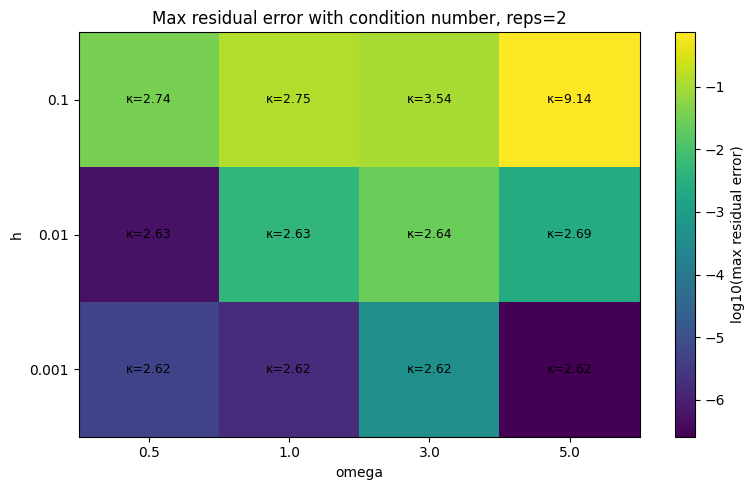

In [13]:
reps_fixed = 2

sub = df[df["reps"] == reps_fixed]

err_pivot = sub.pivot(index="h", columns="omega", values="max_residual")
kappa_pivot = sub.pivot(index="h", columns="omega", values="condition_number")

plt.figure(figsize=(8,5))

im = plt.imshow(
    np.log10(err_pivot.values),
    aspect="auto",
    origin="lower"
)

plt.colorbar(im, label="log10(max residual error)")

plt.xticks(range(len(err_pivot.columns)), err_pivot.columns)
plt.yticks(range(len(err_pivot.index)), err_pivot.index)

plt.xlabel("omega")
plt.ylabel("h")
plt.title(f"Max residual error with condition number, reps={reps_fixed}")

# Add condition number text in each box
for i in range(len(err_pivot.index)):
    for j in range(len(err_pivot.columns)):
        kappa_val = kappa_pivot.values[i, j]
        plt.text(
            j, i,
            f"κ={kappa_val:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()

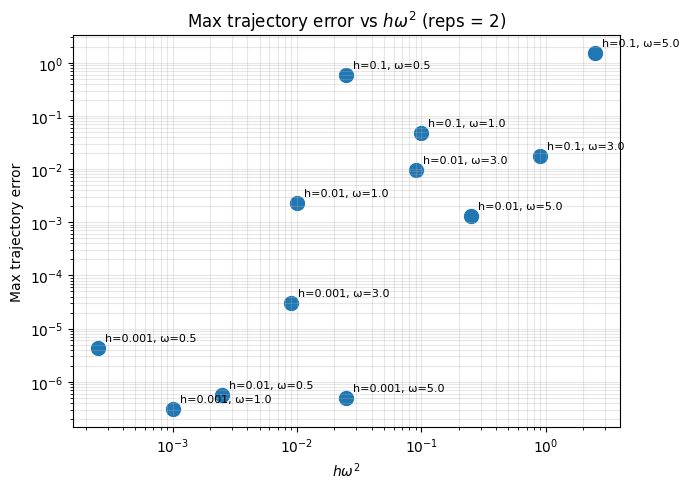

In [14]:

sub = df[df["reps"] == 2].copy()
sub["h_omega2"] = sub["h"] * (sub["omega"]**2)

plt.figure(figsize=(7,5))
plt.scatter(sub["h_omega2"], sub["max_error"], s=100)

for _, row in sub.iterrows():
    plt.annotate(
        f"h={row['h']}, ω={row['omega']}",
        (row["h_omega2"], row["max_error"]),
        textcoords="offset points",
        xytext=(5,5),
        fontsize=8
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$h\omega^2$")
plt.ylabel("Max trajectory error")
plt.title(r"Max trajectory error vs $h\omega^2$ (reps = 2)")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

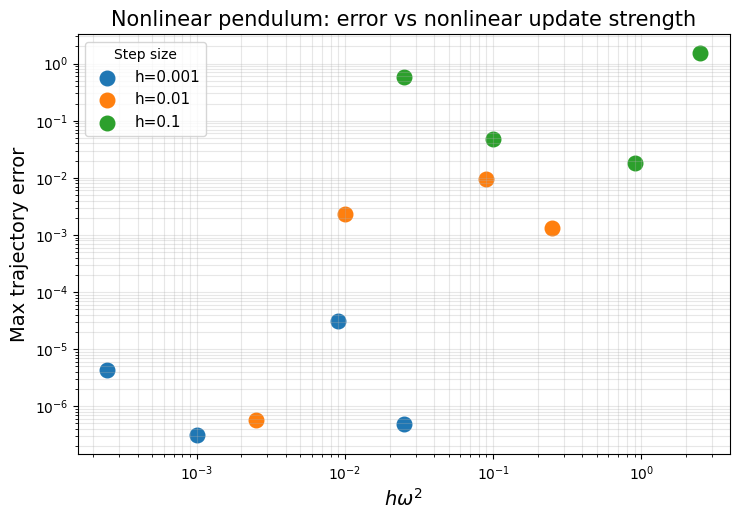

In [15]:
import numpy as np
import matplotlib.pyplot as plt

sub = df[df["reps"] == 2].copy()
sub["h_omega2"] = sub["h"] * sub["omega"]**2

plt.figure(figsize=(7.5,5.3))

for h in sorted(sub["h"].unique()):
    s = sub[sub["h"] == h]
    plt.scatter(
        s["h_omega2"],
        s["max_error"],
        s=110,
        label=f"h={h}"
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$h\omega^2$", fontsize=14)
plt.ylabel("Max trajectory error", fontsize=14)
plt.title(r"Nonlinear pendulum: error vs nonlinear update strength", fontsize=15)
plt.grid(True, which="both", alpha=0.3)
plt.legend(title="Step size", fontsize=11)

plt.tight_layout()
plt.savefig("nonlinear_error_vs_homega2_clean.png", dpi=300, bbox_inches="tight")
plt.show()